<a href="https://colab.research.google.com/github/yg36/LangGraph-Learnings/blob/main/Langgraph_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
  number1 : int
  number2 : int
  number3 : int
  number4 : int
  operation1 : str
  operation2 : str
  answer1: int
  answer2: int

In [16]:
def adder1(state: AgentState) -> AgentState:
  state['answer1'] = state['number1'] + state['number2']
  return state

def adder2(state: AgentState) -> AgentState:
  state['answer2'] = state['number3'] + state['number4']
  return state

def subtractor1(state: AgentState) -> AgentState:
  state['answer1'] = state['number1'] - state['number2']
  return state

def subtractor2(state: AgentState) -> AgentState:
  state['answer2'] = state['number3'] - state['number4']
  return state

def decide_next_state1(state: AgentState) -> str:
  if state['operation1'] == '+':
    return "addition_edge"
  elif state['operation1'] == '-':
    return "subtract_edge"

def decide_next_state2(state: AgentState) -> str:
  if state['operation2'] == '+':
    return "addition_edge"
  elif state['operation2'] == '-':
    return "subtract_edge"

In [20]:
graph = StateGraph(AgentState)

graph.add_node("add1", adder1)
graph.add_node("add2", adder2)

graph.add_node("subtractor1", subtractor1)
graph.add_node("subtractor2", subtractor2)

graph.add_node("decide1", lambda state: state)
graph.add_node("decide2", lambda state: state)

graph.add_edge(START, "decide1")

graph.add_conditional_edges("decide1", decide_next_state1,
                            {
                                "addition_edge": "add1",
                                "subtract_edge": "subtractor1"
                            })

graph.add_conditional_edges("decide2", decide_next_state2,
                            {
                                "addition_edge": "add2",
                                "subtract_edge": "subtractor2"
                            })
graph.add_edge("add1", "decide2")
graph.add_edge("subtractor1", "decide2")

graph.add_edge("add2", END)
graph.add_edge("subtractor2", END)

app = graph.compile()

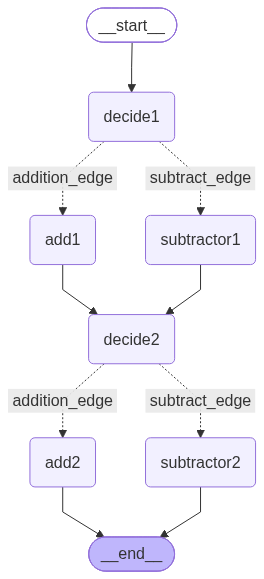

In [21]:
app

In [22]:
results = app.invoke({
    "number1": 10,
    "number2": 5,
    "number3": 20,
    "number4": 4,
    "operation1": "+",
    "operation2": "-"
    })

In [23]:
results

{'number1': 10,
 'number2': 5,
 'number3': 20,
 'number4': 4,
 'operation1': '+',
 'operation2': '-',
 'answer1': 15,
 'answer2': 16}